### Técnica XGBoost

**Carga de datos desde MinIO**

In [1]:
import os
import sys
import pandas as pd
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

ruta_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ruta_raiz not in sys.path:
    sys.path.insert(0, ruta_raiz)


access_key = os.getenv("MINIO_ACCESS_KEY")
if access_key is None:
    raise AssertionError("MINIO_ACCESS_KEY no definida.")

secret_key = os.getenv("MINIO_SECRET_KEY")
if secret_key is None:
    raise AssertionError("MINIO_SECRET_KEY no definida.")


meses = ['01', '02']
dfs = []

for mes in meses:
    try:
        s = download_df_parquet(
            access_key=access_key,
            secret_key=secret_key,
            object_name=f"grupo5/final/year=2025/month={mes}/dataset_final.parquet",
        )
        dfs.append(s)
    except Exception as e:
        print(f"  Sin datos para mes {mes}: {e}")

df = pd.concat(dfs, ignore_index=True)

print(f"¡Descarga exitosa! {len(meses)} meses")
print(f"  df: {len(df):,} filas")


¡Descarga exitosa! 2 meses
  df: 12,085,095 filas


**Creación de nuevas features para una ventana de tiempo más amplia**

In [3]:
#Ordenamos por línea, parada y timestamp
df = df.sort_values(['route_id', 'stop_id', 'merge_time'])
grupo = ['route_id', 'stop_id']

#Creación de nuevas variables de delay para poder ampliar la ventana de observaciones a 30 minutos aproximadamente
df['lagged_delay_3'] = df.groupby(grupo)['delay_seconds'].shift(3)
df['lagged_delay_4'] = df.groupby(grupo)['delay_seconds'].shift(4)

**Selección de features y target**

In [4]:
#Seleccion de variables
features = [
    'delay_seconds', 'lagged_delay_1', 'lagged_delay_2',
    'lagged_delay_3', 'lagged_delay_4',
    'route_rolling_delay', 'actual_headway_seconds',
    'is_unscheduled', 'num_updates', 'scheduled_time_to_end',
    'stops_to_end', 'route_id', 'direction',
    'hour_sin', 'hour_cos', 'dow', 'is_weekend',
    'n_eventos_afectando', 'tipo_referente',
    'afecta_previo', 'afecta_durante', 'afecta_despues',
    'temp_extreme', 'category',
]
target = 'alert_in_next_15m'


# Eliminar filas sin target
df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(int)

**Filtro que elimina paradas que no tienen alerta en 15m pero su comportamiento puede estar alterado por alerta en 30m**

In [5]:
mask_positivos = df[target] == 1
mask_negativos_limpios = (
    df['alert_in_next_30m'] == 0            
)

df = df[mask_positivos | mask_negativos_limpios].copy()
df = df.reset_index(drop=True)

print(f"Dataset tras filtrar negativos ambiguos: {len(df):,} filas")
print(f"  Positivos: {df[target].sum():,} ({df[target].mean()*100:.1f}%)")
print(f"  Negativos: {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%)")

Dataset tras filtrar negativos ambiguos: 11,341,612 filas
  Positivos: 1,093,820 (9.6%)
  Negativos: 10,247,792 (90.4%)


**División de los datos en Train-Val-Test**

In [6]:
df_sorted = df.sort_values('merge_time')

#Division X e y
X = df_sorted[features]
y = df_sorted[target]

print(f"Features: {len(features)}")
print(f"Filas:    {len(X):,}")
print(f"\nDistribución del target:")
print(y.value_counts(normalize=True).round(3))


#División de los datos en Entrenamiento-Validación-Test

dias = df_sorted['merge_time'].dt.date.unique()
dias_ordenados = sorted(dias)

total_dias = len(dias_ordenados)
corte_70   = dias_ordenados[int(total_dias * 0.70)]
corte_85   = dias_ordenados[int(total_dias * 0.85)]

print(f"Total días: {total_dias}")
print(f"Primer día: {dias_ordenados[0]}")
print(f"Último día: {dias_ordenados[-1]}")
print(f"\nCorte train (70%): {corte_70}")
print(f"Corte val   (85%): {corte_85}")


train = df_sorted[df_sorted['merge_time'].dt.date <  corte_70]
val   = df_sorted[(df_sorted['merge_time'].dt.date >= corte_70) &
           (df_sorted['merge_time'].dt.date <  corte_85)]
test  = df_sorted[df_sorted['merge_time'].dt.date >= corte_85]

X_train, y_train = train[features], train[target]
X_val,   y_val   = val[features],   val[target]
X_test,  y_test  = test[features],  test[target]

n = len(df)
print(f"Train: {len(train):,} ({len(train)/n*100:.0f}%)  "
      f"{train['merge_time'].min().date()} → {train['merge_time'].max().date()}")
print(f"Val:   {len(val):,} ({len(val)/n*100:.0f}%)  "
      f"{val['merge_time'].min().date()} → {val['merge_time'].max().date()}")
print(f"Test:  {len(test):,} ({len(test)/n*100:.0f}%)  "
      f"{test['merge_time'].min().date()} → {test['merge_time'].max().date()}")

"""
n        = len(df_sorted)
i_train  = int(n * 0.70)
i_val    = int(n * 0.85)

X_train, y_train = X.iloc[:i_train], y.iloc[:i_train]
X_val, y_val = X.iloc[i_train:i_val], y.iloc[i_train:i_val]
X_test, y_test = X.iloc[i_val:], y.iloc[i_val:]

print(f"Train: {len(X_train):,}  ({len(X_train)/n*100:.0f}%)")
print(f"Val:   {len(X_val):,}  ({len(X_val)/n*100:.0f}%)")
print(f"Test:  {len(X_test):,}  ({len(X_test)/n*100:.0f}%)")
"""

Features: 24
Filas:    11,341,612

Distribución del target:
alert_in_next_15m
0    0.904
1    0.096
Name: proportion, dtype: float64
Total días: 59
Primer día: 2025-01-01
Último día: 2025-02-28

Corte train (70%): 2025-02-11
Corte val   (85%): 2025-02-20
Train: 7,845,635 (69%)  2025-01-01 → 2025-02-10
Val:   1,699,581 (15%)  2025-02-11 → 2025-02-19
Test:  1,796,396 (16%)  2025-02-20 → 2025-02-28


'\nn        = len(df_sorted)\ni_train  = int(n * 0.70)\ni_val    = int(n * 0.85)\n\nX_train, y_train = X.iloc[:i_train], y.iloc[:i_train]\nX_val, y_val = X.iloc[i_train:i_val], y.iloc[i_train:i_val]\nX_test, y_test = X.iloc[i_val:], y.iloc[i_val:]\n\nprint(f"Train: {len(X_train):,}  ({len(X_train)/n*100:.0f}%)")\nprint(f"Val:   {len(X_val):,}  ({len(X_val)/n*100:.0f}%)")\nprint(f"Test:  {len(X_test):,}  ({len(X_test)/n*100:.0f}%)")\n'

**Encoding de categorías**

In [8]:
#Encodear categorías

from sklearn.preprocessing import LabelEncoder

cols_categoricas = X_train.select_dtypes(
    include=['object', 'category', 'str']
).columns.tolist()

print(f"Columnas a encodear: {cols_categoricas}")

encoders = {}
for col in cols_categoricas:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))

    known_labels = set(le.classes_)

    X_val[col] = X_val[col].astype(str).apply(
        lambda x: x if x in known_labels else le.classes_[0]
    )
    X_val[col] = le.transform(X_val[col])
    
    X_test[col] = X_test[col].astype(str).apply(
        lambda x: x if x in known_labels else le.classes_[0]
    )
    X_test[col] = le.transform(X_test[col])
    
    encoders[col] = le

print("✓ Encoding completado")

Columnas a encodear: ['route_id', 'direction', 'tipo_referente', 'category']
✓ Encoding completado


**Búsqueda de los mejores hiperparámetros empleando optuna**

In [9]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score, classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              recall_score, precision_score)

# Ratio de desbalance para scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio desbalance: {ratio:.1f}:1")

def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'n_estimators':     500,
        'scale_pos_weight': ratio,
        'tree_method':      'hist',
        'eval_metric':      'aucpr',
        'early_stopping_rounds': 20,
    }
    modelo = XGBClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = modelo.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print(study.best_params)

[I 2026-03-17 11:36:24,869] A new study created in memory with name: no-name-f4cac662-f0a2-4033-9b61-01ec9c4737cd


Ratio desbalance: 9.3:1


[I 2026-03-17 11:37:55,001] Trial 0 finished with value: 0.2016239591918385 and parameters: {'max_depth': 6, 'learning_rate': 0.025551021746928106, 'subsample': 0.5788944314408464, 'colsample_bytree': 0.5574522378210649, 'min_child_weight': 38, 'gamma': 4.052195471963026, 'reg_alpha': 0.3291149964740117}. Best is trial 0 with value: 0.2016239591918385.
[I 2026-03-17 11:38:38,863] Trial 1 finished with value: 0.19891734737692068 and parameters: {'max_depth': 5, 'learning_rate': 0.046798937519665434, 'subsample': 0.7427923607800868, 'colsample_bytree': 0.6643369066452665, 'min_child_weight': 20, 'gamma': 0.04047237263133996, 'reg_alpha': 0.00041651551002860567}. Best is trial 0 with value: 0.2016239591918385.
[I 2026-03-17 11:39:30,308] Trial 2 finished with value: 0.20420101225338053 and parameters: {'max_depth': 7, 'learning_rate': 0.096396462704253, 'subsample': 0.8218222522837988, 'colsample_bytree': 0.6034499417733403, 'min_child_weight': 44, 'gamma': 1.7429395946857884, 'reg_alpha'

{'max_depth': 6, 'learning_rate': 0.07566329435869733, 'subsample': 0.7254977661110588, 'colsample_bytree': 0.5413817514652193, 'min_child_weight': 33, 'gamma': 1.099138952263543, 'reg_alpha': 1.6832413152707857}


**Entrenamiento del modelo empleando los mejores parámetros**

In [10]:
best_params = study.best_params

params_fijos = {
    'n_estimators': 500,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'aucpr',
    'random_state': 42
}

parametros = {**params_fijos, **best_params}

modelo_final = XGBClassifier(**parametros)
modelo_final.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5413817514652193
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

**Evaluacion del modelo**

In [11]:
import numpy as np

#Evaluación del modelo

y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Threshold óptimo por F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int),
                        zero_division=0) for t in thresholds]
threshold_opt = thresholds[np.argmax(f1_scores)]
y_pred = (y_prob >= threshold_opt).astype(int)


print(f"Threshold óptimo: {threshold_opt:.2f}")
print(f"\nAUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob):.4f}")
print(f"F1      : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

Threshold óptimo: 0.55

AUC-ROC : 0.6632
PR-AUC  : 0.1553
F1      : 0.2002
Recall  : 0.4756
Precision: 0.1268

              precision    recall  f1-score   support

           0       0.94      0.71      0.81   1651475
           1       0.13      0.48      0.20    144921

    accuracy                           0.69   1796396
   macro avg       0.53      0.59      0.51   1796396
weighted avg       0.87      0.69      0.76   1796396



**Curva Precision-Recall con area sombreada**

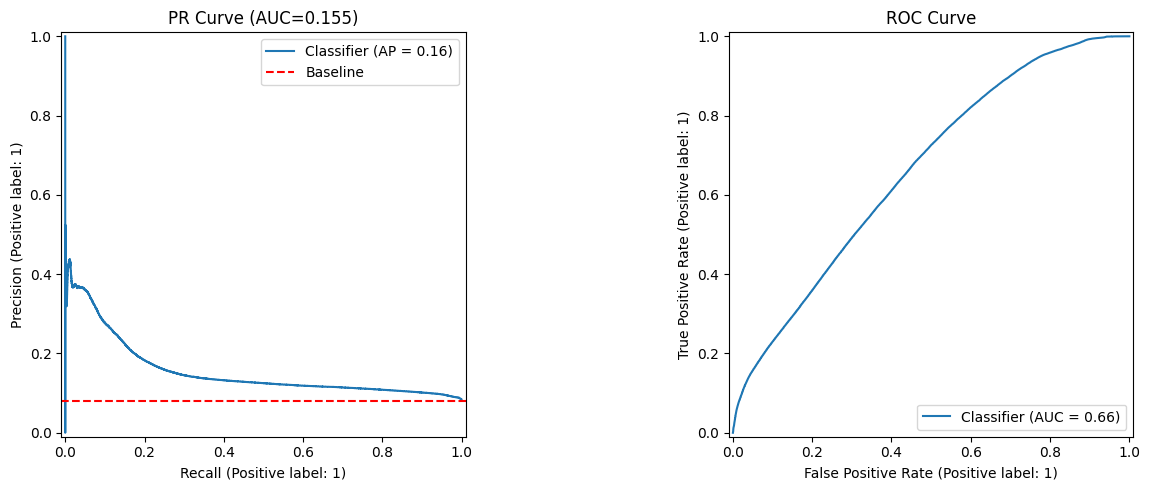

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title(f'PR Curve (AUC={average_precision_score(y_test, y_prob):.3f})')
axes[0].axhline(y=y_test.mean(), color='r', linestyle='--', label='Baseline')
axes[0].legend()

# Curva ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()

**Importancia de features con SHAP**

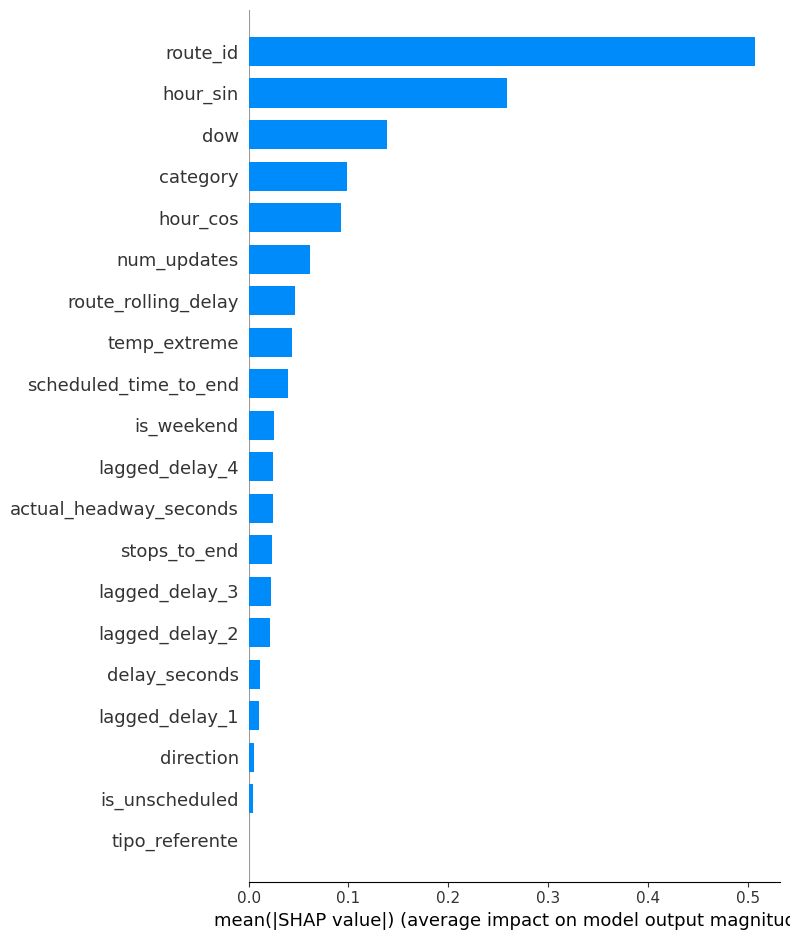

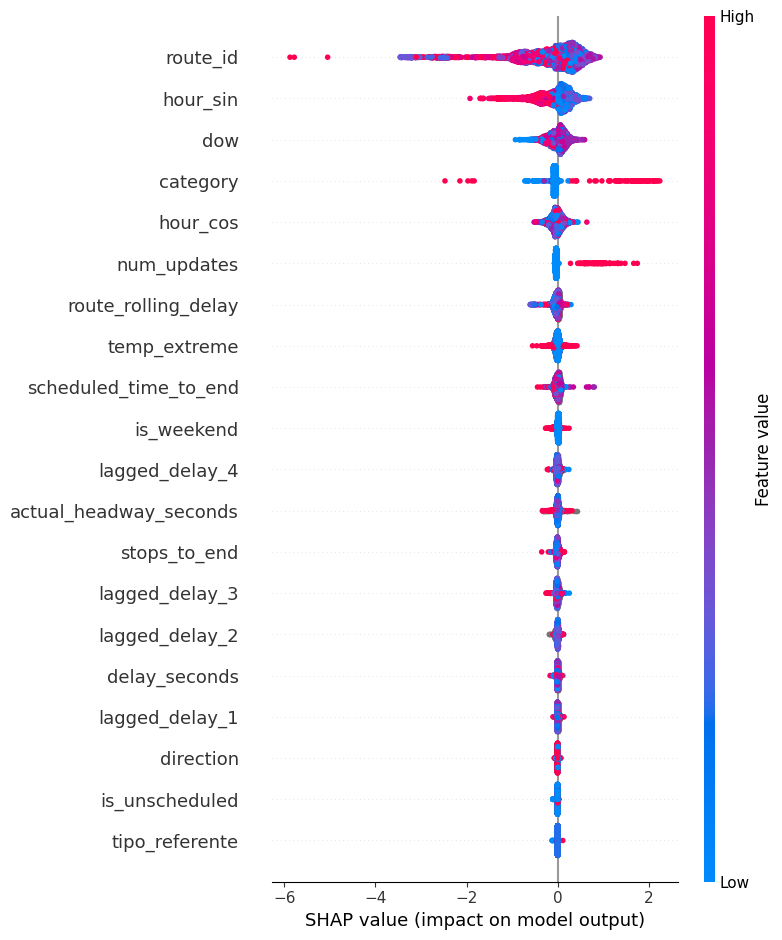

In [13]:
import shap

# Muestra aleatoria para SHAP (costoso con 1.8M filas)
sample = X_test.sample(5000, random_state=42)
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar')   # importancia global
shap.summary_plot(shap_values, sample)                     # dirección del efecto

**Matriz de confusión con costes**

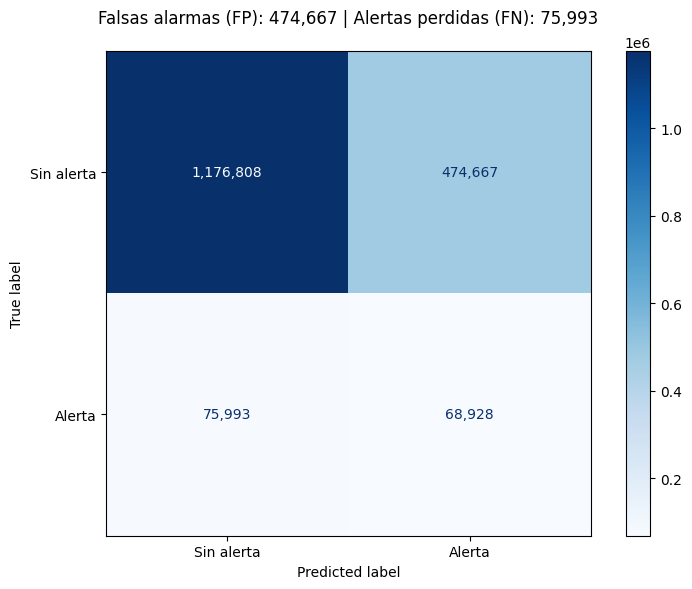

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=['Sin alerta', 'Alerta'],
    cmap='Blues',
    ax=ax,
    values_format=',d'
)

fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

ax.set_title(f'Falsas alarmas (FP): {fp:,} | Alertas perdidas (FN): {fn:,}', 
             pad=20,     
             fontsize=12)

plt.tight_layout() 
plt.show()